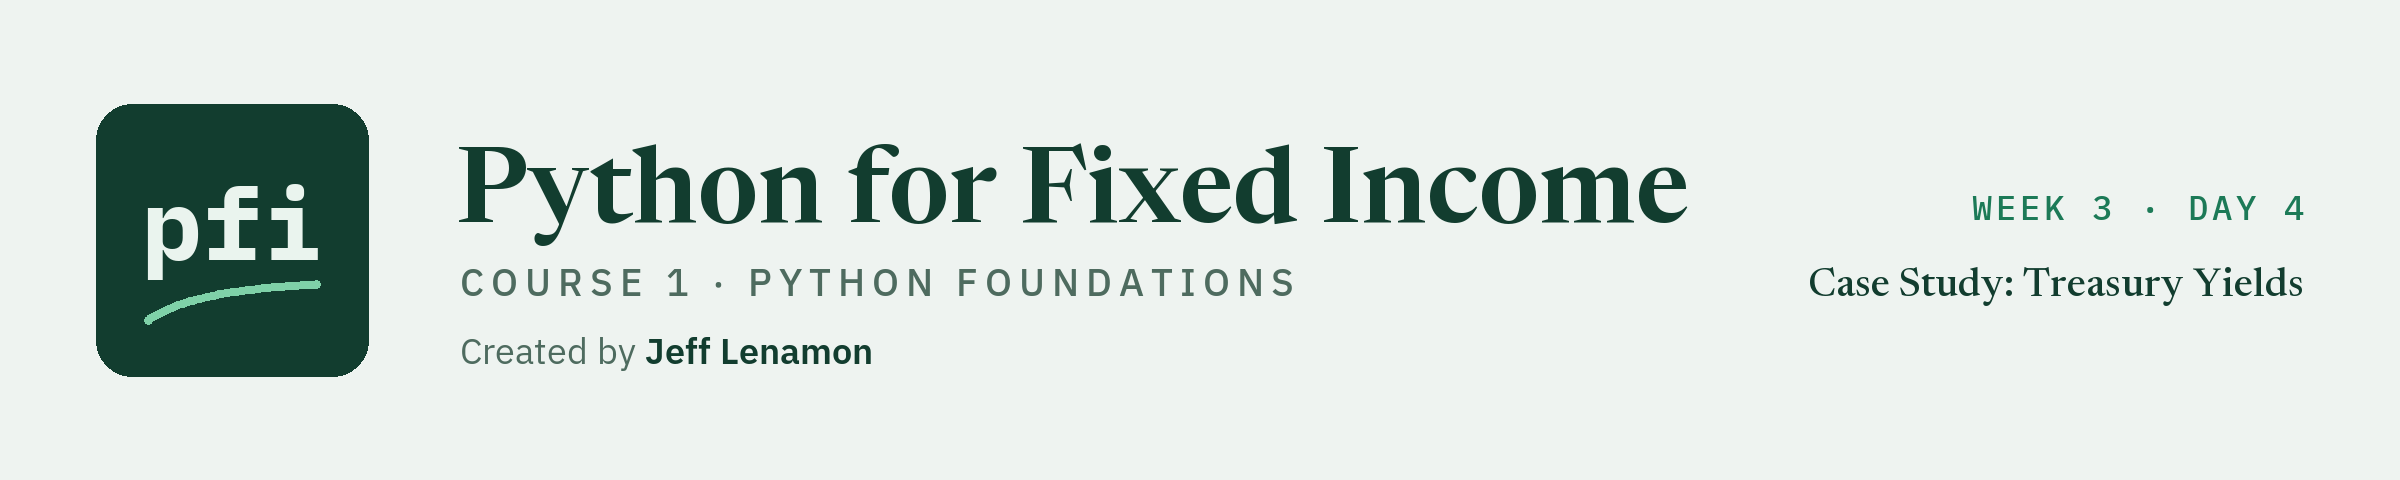

# Case Study: Treasury Yields

Week 3. Daily Treasury par yields from 2015 to 2026 are loaded as a time series and described by tenor, by year, and day by day.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week3/day4/14_case_study_treasury_yields.ipynb)

## Problem Definition

### Context

Every bond on the credit desk is quoted as a spread over a Treasury yield, so the desk keeps a reference sheet of Treasury yields: where each tenor has been, year by year, and how much it has moved in a day. The sheet is out of date. The portfolio manager has asked for a new one, built from the published figures, that can be rebuilt whenever a new file is downloaded.

The request comes with one condition. The sheet is a description. It says what the yields were and when. It does not say why they moved, and it does not say where they are going.

### Objective

You are the desk's analyst. Your job today is to:

* load the file as a time series, with the dates as the row labels,
* check it: its span, the days it has no row for, and the tenors that are blank for part of it,
* describe the yields by tenor and by year, as tables and as charts,
* describe how they moved: over the whole span, between two tenors, and from one day to the next.

### The data

This is the first file in the course that is not invented.

| | |
| --- | --- |
| **Source** | U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates |
| **Page** | https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_yield_curve |
| **Retrieved** | 2026-10-03, from the yearly CSV downloads on that page |
| **Span** | 2015-01-02 to 2026-10-02, one row for each date Treasury published |
| **File** | `treasury_par_yields.csv` in the `data` folder of the course repo, built by `tools/get_treasury_yields.py` |

The figures are as published by Treasury. Nothing has been filled, smoothed, or removed. The only changes are to the layout: the dates are written year-month-day and sorted oldest first.

These are **par yields on Treasury securities**. Treasury describes the series as a par yield curve based on closing market bid prices on the most recently auctioned Treasury securities (https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics). That is a different thing from the corporate portfolio used so far in this course. The portfolio, its issuers, and its CUSIPs are invented. The yields in today's file are real published figures, and no bond from the portfolio appears today.

| Column | Meaning | Units |
| --- | --- | --- |
| `date` | the date of the rates | year-month-day |
| `1 Mo`, `1.5 Month`, `2 Mo`, `3 Mo`, `4 Mo`, `6 Mo` | par yield at each tenor up to six months | percent |
| `1 Yr`, `2 Yr`, `3 Yr`, `5 Yr`, `7 Yr`, `10 Yr`, `20 Yr`, `30 Yr` | par yield at each tenor from one year to thirty | percent |

The column names are Treasury's own labels from its CSV file, which is why one of them reads `1.5 Month` and the others `Mo`.

Units today: **yields are in percent. Spreads and daily changes are in basis points**, which is the difference in percent multiplied by 100.

### The questions the desk wants answered

1. What dates does the file cover, and which days have no row?
2. Which tenors are blank for part of the span, and from what date does each one have values?
3. What were the average, lowest, and highest yields at each tenor, and in each year?
4. How did the 3 Mo, 2 Yr, 10 Yr, and 30 Yr yields move over the span, and on which dates were they highest and lowest?
5. What did the curve look like on chosen dates?
6. What was the 10 Yr less 2 Yr spread, and on how many days in each year was it below zero?
7. How large were the daily changes, and on which dates were the largest?

### How we will work

The order is the one from yesterday: check the file, then one column at a time, then columns against each other. Two things are new. The rows are dates, so the table is a **time series**, and pandas has tools made for that. And the file is real, so every sentence about it has to be a number that the file supports.

Every statement in this notebook describes the data. Nothing here is a forecast or a view, and nothing explains a move.

## 1.0 Loading the file

### 1.1 Importing the libraries

Q. Import the libraries and check which versions are running.

In [1]:
# os is used to find the data folder
import os

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print('pandas version:', pd.__version__)
print('matplotlib version:', matplotlib.__version__)
print('seaborn version:', sns.__version__)

pandas version: 3.0.6
matplotlib version: 3.11.2
seaborn version: 0.13.2


* This notebook was saved with the versions printed above. Yours may differ, and in Google Colab they may be older.

### 1.2 Reading the file

Q. Read the file the way every file has been read so far, and look at the first rows.

In [2]:
# on your own machine the file is in the repo's data folder. In Colab it is read from GitHub.
if os.path.exists('../../../data/treasury_par_yields.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# a plain read_csv, with no extra instructions
raw = pd.read_csv(data_folder + 'treasury_par_yields.csv')

print(raw.shape)
raw.head()

(2940, 15)


,date,1 Mo,1.5 Month,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2015-01-02,0.02,NaN,NaN,0.02,NaN,0.11,0.25,0.66,1.07,1.61,1.92,2.12,2.41,2.69
1,2015-01-05,0.02,NaN,NaN,0.03,NaN,0.10,0.26,0.68,1.06,1.57,1.85,2.04,2.32,2.60
2,2015-01-06,0.02,NaN,NaN,0.03,NaN,0.10,0.25,0.65,1.02,1.50,1.78,1.97,2.25,2.52
3,2015-01-07,0.02,NaN,NaN,0.03,NaN,0.09,0.25,0.62,1.00,1.47,1.76,1.96,2.25,2.52
4,2015-01-08,0.01,NaN,NaN,0.03,NaN,0.08,0.23,0.62,1.00,1.50,1.81,2.03,2.33,2.59


* 2,940 rows and 15 columns: the date and 14 tenors. One row is one date.
* On 2015-01-02 the `1 Mo` yield was 0.02 percent and the `30 Yr` yield was 2.69 percent.
* Three columns show `NaN` in these rows: `1.5 Month`, `2 Mo`, and `4 Mo`. Those cells are blank in the file. Section 2.0 finds out how many there are and where.

Q. What type did pandas give each column?

In [3]:
print(raw.dtypes)

date             str
1 Mo         float64
1.5 Month    float64
2 Mo         float64
3 Mo         float64
4 Mo         float64
6 Mo         float64
1 Yr         float64
2 Yr         float64
3 Yr         float64
5 Yr         float64
7 Yr         float64
10 Yr        float64
20 Yr        float64
30 Yr        float64
dtype: object


* The 14 tenors are `float64`, numbers with a decimal point. The blanks did not stop that: a blank in a number column becomes `NaN` and the column stays a number.
* `date` is `str`, which is text. Older versions of pandas print `object`. As in the last two case studies, `read_csv` does not turn text into dates unless it is told to.
* The row labels are the default ones, 0 to 2,939.

### 1.3 Asking for a year

The desk's questions are about years. In a time series the row labels are dates, and pandas can give the year of every label with `.index.year`.

Q. What is the year of each row?

In [4]:
# index is the row labels of a table. Ask for the year of each one.
raw.index.year

AttributeError: 'RangeIndex' object has no attribute 'year'

* An `AttributeError`, and the last line reads `'RangeIndex' object has no attribute 'year'`. The row labels of this table are a `RangeIndex`, the numbers 0 to 2,939, and a number has no year.
* The dates are in the table, but as a column of text and not as the row labels. Selecting a year by its label fails for the same reason: `raw.loc['2020']` raises a `KeyError`, because no row is labelled `'2020'`.
* Nothing is wrong with the file. It was read without the two instructions a time series needs.

Q. Read the file again, with the dates as dates and as the row labels.

In [5]:
# parse_dates= names the columns to turn into dates
# index_col= names the column to use as the row labels
yields = pd.read_csv(data_folder + 'treasury_par_yields.csv', parse_dates=['date'], index_col='date')

# the 14 tenor names, shortest first, kept for later
tenors = yields.columns.tolist()

print(yields.shape)
print('Type of the row labels:', type(yields.index).__name__)
print('Type of the dates:', yields.index.dtype)
yields.head()

(2940, 14)
Type of the row labels: DatetimeIndex
Type of the dates: datetime64[us]


,1 Mo,1.5 Month,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
date,,,,,,,,,,,,,,
2015-01-02,0.02,NaN,NaN,0.02,NaN,0.11,0.25,0.66,1.07,1.61,1.92,2.12,2.41,2.69
2015-01-05,0.02,NaN,NaN,0.03,NaN,0.10,0.26,0.68,1.06,1.57,1.85,2.04,2.32,2.60
2015-01-06,0.02,NaN,NaN,0.03,NaN,0.10,0.25,0.65,1.02,1.50,1.78,1.97,2.25,2.52
2015-01-07,0.02,NaN,NaN,0.03,NaN,0.09,0.25,0.62,1.00,1.47,1.76,1.96,2.25,2.52
2015-01-08,0.01,NaN,NaN,0.03,NaN,0.08,0.23,0.62,1.00,1.50,1.81,2.03,2.33,2.59


* Still 2,940 rows, and now 14 columns, because the date has moved out of the columns and become the row labels. The table is called `yields`, and `tenors` holds the 14 column names.
* The row labels are a `DatetimeIndex`: an index made of dates. Its type starts with `datetime64`. Older versions of pandas print `datetime64[ns]`.
* A table with a `DatetimeIndex` is a time series. Everything new today depends on it.

Q. Are the dates in order, and is each date there once?

In [6]:
# is_monotonic_increasing is True when each label is later than, or equal to, the one before
print('In date order:', yields.index.is_monotonic_increasing)

# is_unique is True when no label appears twice
print('Each date once:', yields.index.is_unique)

print('First date:', yields.index.min().date())
print('Last date:', yields.index.max().date())

In date order: True
Each date once: True
First date: 2015-01-02
Last date: 2026-10-02


* True and True. The file runs from 2015-01-02 to 2026-10-02, oldest first, with no date repeated.
* Both checks matter for a time series. A change from one row to the next means a change from one day to the next only if the rows are in date order and no date is there twice.

**Excel side by side.** Excel makes the same distinction between a date and text that looks like a date. `=ISNUMBER(A2)` returns TRUE when the cell holds a real date, because Excel stores a date as a number with a date format, and FALSE when it holds text. A date typed as text is converted with `=DATEVALUE(A2)`. Once column A holds real dates, `=YEAR(A2)` returns 2015, `=MIN(A2:A2941)` returns the first date, and `=MAX(A2:A2941)` the last, each shown as a date once the cell has a date format.

| Job | pandas | Excel |
| --- | --- | --- |
| Read the dates as dates | `pd.read_csv(file, parse_dates=['date'])` | `=DATEVALUE(A2)` on a date held as text |
| Is it a real date? | `yields.index.dtype` | `=ISNUMBER(A2)` |
| First and last date | `yields.index.min()`, `yields.index.max()` | `=MIN(A2:A2941)`, `=MAX(A2:A2941)` |
| The year of a date | `yields.index.year` | `=YEAR(A2)` |

In the sheet, the date is in column A and the tenors run from `1 Mo` in column B to `30 Yr` in column O, with the data in rows 2 to 2941. The `2 Yr` is column I and the `10 Yr` is column M.

**Observations: loading the file**

* The file has 2,940 dates from 2015-01-02 to 2026-10-02 and 14 tenors, in date order with no date repeated.
* A plain `read_csv` gives the dates as text and numbers as the row labels, and a year cannot be asked for. `parse_dates` and `index_col` make the table a time series.

## 2.0 Getting to know the time series

### 2.1 Selecting by date

Q. What were the yields on 2020-03-09?

In [7]:
# with a DatetimeIndex, .loc takes a date written as text
yields.loc['2020-03-09']

1 Mo         0.57
1.5 Month     NaN
2 Mo         0.52
3 Mo         0.33
4 Mo          NaN
6 Mo         0.27
1 Yr         0.31
2 Yr         0.38
3 Yr         0.40
5 Yr         0.46
7 Yr         0.56
10 Yr        0.54
20 Yr        0.87
30 Yr        0.99
Name: 2020-03-09 00:00:00, dtype: float64

* One row, returned as a Series with the tenors as its labels. On that date the `10 Yr` was 0.54 percent and the `30 Yr` was 0.99 percent.
* `1.5 Month` and `4 Mo` are `NaN`: the file has no rate for those two tenors on that date.

Q. What was the 10 Yr yield on that date, as a single number?

In [8]:
# .loc[row label, column label]
print('10 Yr on 2020-03-09:', yields.loc['2020-03-09', '10 Yr'], 'percent')

10 Yr on 2020-03-09: 0.54 percent


* 0.54 percent. A row label and a column label together pick out one cell.

**Predict 1**

```
yields.loc['2020'].shape
```

The year 2020 had 366 calendar days. What is printed?

> A) (1, 14), the first row of 2020
>
> B) (366, 14), one row for each calendar day
>
> C) a number of rows near 250, with 14 columns

Decide, then run the cell.

In [9]:
# a year alone selects every row whose date falls in that year
print(yields.loc['2020'].shape)

# a year and a month selects every row of that month
print(yields.loc['2020-03'].shape)

(251, 14)
(22, 14)


* The answer is C: (251, 14). A year can be selected by name now that the row labels are dates. `yields.loc['2020']` returns every row dated in 2020, and there are 251 of them, not 366. The file has a row only for the dates Treasury published.
* `yields.loc['2020-03']` returns the 22 rows of March 2020.
* This is called partial string indexing: give `.loc` part of a date, and it returns every row that matches that part.

**Predict 2**

```
yields.loc['2019-12-30':'2020-01-03', ['2 Yr', '10 Yr']]
```

A slice of a list, such as `prices[0:3]`, leaves out its end. The dates from 30 December to 3 January are five calendar days, all of them weekdays. How many rows come back?

> A) 5
>
> B) 4
>
> C) 3

Decide, then run the cell.

In [10]:
# a slice of dates: from the first label to the last label
yields.loc['2019-12-30':'2020-01-03', ['2 Yr', '10 Yr']]

,2 Yr,10 Yr
date,,
2019-12-30,1.58,1.90
2019-12-31,1.58,1.92
2020-01-02,1.58,1.88
2020-01-03,1.53,1.80


* The answer is B: 4 rows, for 30 and 31 December and 2 and 3 January.
* A slice with `.loc` includes both ends. That is different from a slice of a list by position, which leaves out its end. Here 2020-01-03 is in the result.
* There is no row for 2020-01-01. It was a weekday, and the file has no rate for it. The next section counts the days like it.

**Excel side by side.** A lookup by date is `=XLOOKUP(DATE(2020, 3, 9), A2:A2941, M2:M2941)`, which returns 0.54, the `10 Yr` yield on that date. The older form is `=INDEX(M2:M2941, MATCH(DATE(2020, 3, 9), A2:A2941, 0))`. For a year, turn on Data, Filter and use the date filter on column A to tick 2020. For a range of dates, the same menu has Date Filters, Between.

### 2.2 Rows in each year

Q. How many rows does each year have?

In [11]:
# yields.index.year is the year of each row label
# groupby() on it makes one group per year, and size() counts the rows in each
rows_per_year = yields.groupby(yields.index.year).size()
print(rows_per_year)

date
2015    251
2016    250
2017    250
2018    249
2019    250
2020    251
2021    251
2022    249
2023    250
2024    250
2025    249
2026    190
dtype: int64


* The eleven whole years, 2015 to 2025, have between 249 and 251 rows each. 2026 has 190, because the file ends on 2026-10-02.
* `yields.index.year` gives the year of every row, the request that failed in section 1.3. It needed no new column, because the dates are the index. Other parts of a date work the same way: `.month`, `.day`, and `.dayofweek`.
* 2026 is a part year. Any figure for 2026 in this notebook covers 2 January to 2 October and is not comparable with a whole year without saying so.

**Excel side by side.** Add a helper column P with `=YEAR(A2)`, filled down. Then `=COUNTIF(P2:P2941, 2020)` returns 251. A pivot table does all the years at once: put `date` in Rows, right-click a date, choose Group, pick Years, and put Count of `10 Yr` in Values.

### 2.3 Days with no row

Q. Does the file have any Saturdays or Sundays?

In [12]:
# dayofweek is 0 for Monday up to 6 for Sunday
print(pd.Series(yields.index.dayofweek).value_counts().sort_index())

date
0    538
1    608
2    604
3    596
4    594
Name: count, dtype: int64


* Only the values 0 to 4 appear, Monday to Friday. There is no Saturday or Sunday in the file.
* The five counts are not equal: 538 Mondays against 608 Tuesdays. Some weekdays have no row.

Q. Is there a row for 2024-07-04, a Thursday?

In [13]:
# 'in' asks whether a label is in the index. The answer is True or False, and no error is raised.
print('2024-07-04 in the file:', '2024-07-04' in yields.index)
print('2024-07-05 in the file:', '2024-07-05' in yields.index)

2024-07-04 in the file: False
2024-07-05 in the file: True


* False and True. There is no row for Thursday 2024-07-04 and there is one for the Friday after it.
* Asking for a missing date with `yields.loc['2024-07-04']` raises a `KeyError`, because no row has that label. Testing with `in` first avoids the error.

Q. Which weekdays between the first and last date have no row?

In [14]:
# date_range() builds a run of dates. freq='B' keeps Monday to Friday only.
weekdays = pd.date_range(yields.index.min(), yields.index.max(), freq='B')

# difference() keeps the dates of the first index that are not in the second
no_row = weekdays.difference(yields.index)

print('Weekdays in the span:', len(weekdays))
print('Rows in the file:', len(yields))
print('Weekdays with no row:', len(no_row))

# the ones in 2024
print(no_row[no_row.year == 2024].strftime('%Y-%m-%d').tolist())

Weekdays in the span: 3066
Rows in the file: 2940
Weekdays with no row: 126
['2024-01-01', '2024-01-15', '2024-02-19', '2024-03-29', '2024-05-27', '2024-06-19', '2024-07-04', '2024-09-02', '2024-10-14', '2024-11-11', '2024-11-28', '2024-12-25']


* 3,066 weekdays from the first date to the last, 2,940 rows, and 126 weekdays with no row. 3,066 less 126 is 2,940, so every row in the file is a weekday and the two counts account for each other.
* The 12 in 2024 include 2024-01-01, 2024-07-04, and 2024-12-25. A weekday with no row is a date for which the file has no rates. Three of the 12 are fixed-date U.S. public holidays: 1 January, 4 July, and 25 December. The file itself gives no reason for any of them.
* These days are **absent**, not blank. There is no row with empty cells for 2024-07-04. The row is not there at all, so `isna()` cannot find it. It was found by building the list of dates that could be there and comparing.

**Excel side by side.** `=SUMPRODUCT(--(WEEKDAY(A2:A2941, 2) > 5))` counts the Saturdays and Sundays in column A and returns 0. With 2 as its second argument, `WEEKDAY` returns 1 for Monday up to 7 for Sunday. `=NETWORKDAYS(A2, A2941)` counts the weekdays from the first date to the last and returns 3,066, and `=NETWORKDAYS(A2, A2941) - COUNT(A2:A2941)` returns 126. A lookup of a date with no row, `=XLOOKUP(DATE(2024, 7, 4), A2:A2941, M2:M2941)`, returns `#N/A`, which is Excel's version of the `KeyError`.

### 2.4 Blank cells

Q. How many values are missing in each column?

In [15]:
# isna() is True for each missing cell, and sum() counts the Trues in each column
missing = yields.isna().sum()

# only the columns with at least one missing value
print(missing[missing > 0])
print('Missing values in the whole table:', missing.sum())

1.5 Month    2532
2 Mo          949
4 Mo         1951
dtype: int64
Missing values in the whole table: 5432


* Three tenors have blanks: `1.5 Month` with 2,532, `2 Mo` with 949, and `4 Mo` with 1,951. That is 5,432 blank cells. The other eleven tenors have a value on all 2,940 dates.

Q. Where are the blanks? On what date does each of the three tenors first have a value, and is it ever blank after that?

In [16]:
for tenor in ['2 Mo', '4 Mo', '1.5 Month']:
    # first_valid_index() is the label of the first row that is not missing
    first = yields[tenor].first_valid_index()

    # count the blanks from that date onward
    blanks_after = yields.loc[first:, tenor].isna().sum()

    print(tenor, '- first value on', first.date(), ' values:', yields[tenor].count(), ' blanks after the first value:', blanks_after)

2 Mo - first value on 2018-10-16  values: 1991  blanks after the first value: 0
4 Mo - first value on 2022-10-19  values: 989  blanks after the first value: 0
1.5 Month - first value on 2025-02-18  values: 408  blanks after the first value: 0


* `2 Mo` first has a value on 2018-10-16, `4 Mo` on 2022-10-19, and `1.5 Month` on 2025-02-18. After its first value, none of the three is ever blank.
* So the blanks are not scattered. Each of the three tenors is blank from the start of the file up to the day of its first value, and complete from then on.
* That pattern decides how to treat them. A scattered blank could be a lost value. These are dates before the tenor has any value in the file, and there is nothing to fill in. They stay blank.

Q. The `2 Mo` begins partway through 2018. What does that do to its 2018 average?

In [17]:
# len() counts the rows of 2018. count() counts the values that are not missing.
print('Rows in 2018:', len(yields.loc['2018']))
print('2 Mo values in 2018:', yields.loc['2018', '2 Mo'].count())
print('2 Mo mean in 2018:', round(yields.loc['2018', '2 Mo'].mean(), 2), 'percent')
print('3 Mo mean in 2018:', round(yields.loc['2018', '3 Mo'].mean(), 2), 'percent')
print('3 Mo mean from 2018-10-16:', round(yields.loc['2018-10-16':'2018-12-31', '3 Mo'].mean(), 2), 'percent')

Rows in 2018: 249
2 Mo values in 2018: 51
2 Mo mean in 2018: 2.33 percent
3 Mo mean in 2018: 1.97 percent
3 Mo mean from 2018-10-16: 2.38 percent


* 2018 has 249 rows and the `2 Mo` has a value on 51 of them. Its 2018 mean, 2.33 percent, is an average of 51 days from 16 October to the end of the year.
* The `3 Mo` mean for all of 2018 is 1.97 percent. Over the same 51 days as the `2 Mo` it is 2.38 percent. The two figures for the `3 Mo` differ by 0.41 because they cover different days.
* As yesterday, `mean()` leaves missing values out without a word. Put `count()` next to any average of a column that has blanks. An average over part of a year is not a yearly average, and a table should say so.

**Excel side by side.** `=COUNTBLANK(D2:D2941)` counts the empty cells of the `2 Mo` column and returns 949, and `=COUNT(D2:D2941)` counts the numbers and returns 1,991. `=AVERAGE(D2:D2941)` leaves the empty cells out of both the sum and the count, as `mean()` does. The first date with a value is `=XLOOKUP(TRUE, ISNUMBER(D2:D2941), A2:A2941)`, which returns 2018-10-16 once the cell has a date format.

**Observations: getting to know the time series**

* A year, a month, a single date, or a range of dates can be selected with `.loc` once the index is a `DatetimeIndex`. A date slice includes both ends.
* The whole years have 249 to 251 rows. 2026 has 190 and is a part year.
* 126 weekdays in the span have no row at all. They are absent from the file, not blank in it.
* Three tenors begin partway: `2 Mo` on 2018-10-16, `4 Mo` on 2022-10-19, and `1.5 Month` on 2025-02-18. Each is blank before its first date and complete after it. Nothing is filled.

## 3.0 Yields by tenor and by year

### 3.1 Each tenor over the whole span

Q. What are the summary statistics of each tenor?

In [18]:
# describe() makes one column of statistics per tenor. T turns the table on its side, one row per tenor.
yields.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
1 Mo,2940.0,2.10,1.98,0.00,0.15,1.62,4.00,6.02
1.5 Month,408.0,4.02,0.29,3.65,3.72,4.00,4.35,4.53
2 Mo,1991.0,2.82,2.02,0.00,0.28,3.34,4.46,5.61
3 Mo,2940.0,2.16,1.96,0.00,0.23,1.69,4.09,5.63
4 Mo,989.0,4.66,0.66,3.58,4.04,4.52,5.41,5.64
6 Mo,2940.0,2.22,1.91,0.02,0.39,1.87,4.08,5.61
1 Yr,2940.0,2.24,1.79,0.04,0.52,1.94,4.00,5.49
2 Yr,2940.0,2.28,1.60,0.09,0.75,2.08,3.90,5.19
3 Yr,2940.0,2.34,1.48,0.10,1.00,2.15,3.82,5.03
5 Yr,2940.0,2.47,1.32,0.19,1.41,2.25,3.80,5.09


Read the `count` column first.

* Eleven tenors have 2,940 values. `2 Mo` has 1,991, `4 Mo` has 989, and `1.5 Month` has 408.
* Among the eleven complete tenors, the mean rises with the tenor, from 2.10 percent for the `1 Mo` to 3.22 percent for the `30 Yr`. The standard deviation falls, from 1.98 for the `1 Mo` to 1.06 for the `30 Yr`: over this span the short tenors varied more than the long ones.
* The lowest value in the table is 0.00 percent, for the `1 Mo`, `2 Mo`, and `3 Mo`. The highest is 6.02 percent, for the `1 Mo`.
* The `10 Yr` ran from 0.52 to 5.29 percent, with a mean of 2.76 and a median of 2.49.
* The three part-span tenors do not fit the pattern: the `4 Mo` mean is 4.66 percent and the `1.5 Month` mean is 4.02. Those are averages over 989 and 408 recent dates, not over the 2,940 dates of the others. Their rows cannot be compared with the rest of the table.

**Excel side by side.**

| Job | pandas | Excel | Result for the `10 Yr` |
| --- | --- | --- | --- |
| Mean | `yields['10 Yr'].mean()` | `=AVERAGE(M2:M2941)` | 2.76 |
| Median | `yields['10 Yr'].median()` | `=MEDIAN(M2:M2941)` | 2.49 |
| Lowest | `yields['10 Yr'].min()` | `=MIN(M2:M2941)` | 0.52 |
| Highest | `yields['10 Yr'].max()` | `=MAX(M2:M2941)` | 5.29 |
| Standard deviation | `yields['10 Yr'].std()` | `=STDEV.S(M2:M2941)` | 1.19 |

### 3.2 One tenor, year by year

Q. What were the average, lowest, and highest 10 Yr yield in each year, and how wide was the range?

In [19]:
# group the rows by year, take the 10 Yr column, and work out three statistics for each year
by_year = yields.groupby(yields.index.year)['10 Yr'].agg(['mean', 'min', 'max'])
by_year.index.name = 'year'

# the range of the year in basis points: highest less lowest, in percent, times 100
# round() removes the tiny error of decimal arithmetic, and astype(int) shows whole numbers
by_year['range_bp'] = ((by_year['max'] - by_year['min']) * 100).round().astype(int)

by_year.round(2)

,mean,min,max,range_bp
year,,,,
2015,2.14,1.68,2.50,82
2016,1.84,1.37,2.60,123
2017,2.33,2.05,2.62,57
2018,2.91,2.44,3.24,80
2019,2.14,1.47,2.79,132
2020,0.89,0.52,1.88,136
2021,1.45,0.93,1.74,81
2022,2.95,1.63,4.25,262
2023,3.96,3.30,4.98,168


* The lowest yearly mean is 0.89 percent, in 2020. The highest for a whole year is 4.29 percent, in 2025. The part year 2026 has a mean of 4.47 percent so far.
* The widest range in one year is 262 basis points, in 2022, from 1.63 to 4.25 percent. The narrowest is 57 basis points, in 2017, from 2.05 to 2.62 percent.
* A subtraction of two yields such as 4.25 less 1.63 can come out as 2.6199999999999997 in any program that stores decimals in binary. Multiplying by 100 and rounding gives the whole number of basis points, 262.

Q. What was the average yield in each year for four tenors: 3 Mo, 2 Yr, 10 Yr, and 30 Yr?

In [20]:
# the four tenors used for the rest of the notebook
main = ['3 Mo', '2 Yr', '10 Yr', '30 Yr']

# the mean of each of the four, for each year
mean_by_year = yields.groupby(yields.index.year)[main].mean()
mean_by_year.index.name = 'year'

mean_by_year.round(2)

,3 Mo,2 Yr,10 Yr,30 Yr
year,,,,
2015,0.05,0.69,2.14,2.84
2016,0.32,0.83,1.84,2.59
2017,0.95,1.40,2.33,2.89
2018,1.97,2.53,2.91,3.11
2019,2.11,1.97,2.14,2.58
2020,0.36,0.39,0.89,1.56
2021,0.04,0.27,1.45,2.06
2022,2.09,2.99,2.95,3.11
2023,5.28,4.58,3.96,4.09


* The `3 Mo` yearly mean runs from 0.04 percent in 2021 to 5.28 percent in 2023. The `30 Yr` runs from 1.56 percent in 2020 to 5.01 percent in the part year 2026.
* In seven of the twelve years the four means rise from left to right: 2015 to 2018, 2020, 2021, and 2026. In 2023 and 2024 the `3 Mo` mean, 5.28 and 5.18 percent, is above the `10 Yr` mean, 3.96 and 4.21 percent.
* Each of the four tenors has its lowest yearly mean in 2020 or 2021.

**Excel side by side.** With the year in helper column P:

| Job | pandas | Excel | Result for 2020 |
| --- | --- | --- | --- |
| Mean of a year | `by_year.loc[2020, 'mean']` | `=AVERAGEIFS(M2:M2941, P2:P2941, 2020)` | 0.89 |
| Highest of a year | `by_year.loc[2020, 'max']` | `=MAXIFS(M2:M2941, P2:P2941, 2020)` | 1.88 |
| Lowest of a year | `by_year.loc[2020, 'min']` | `=MINIFS(M2:M2941, P2:P2941, 2020)` | 0.52 |
| Range in basis points | `by_year.loc[2020, 'range_bp']` | `=(MAXIFS(M2:M2941, P2:P2941, 2020) - MINIFS(M2:M2941, P2:P2941, 2020)) * 100` | 136 |

`MAXIFS` and `MINIFS` are in Excel 2019 and later. Without the helper column, the year can be given as two date conditions: `=AVERAGEIFS(M2:M2941, A2:A2941, ">=" & DATE(2020, 1, 1), A2:A2941, "<=" & DATE(2020, 12, 31))`. The whole table is a pivot table: `date` in Rows, grouped by Years, with the `10 Yr` in Values three times, summarized by Average, Min, and Max. The `groupby` line is that pivot table written as code, and it is rebuilt by running the cell again on a new file.

### 3.3 Wide and long

The file is in **wide** shape: one row per date and one column per tenor. That shape suits a time series. Picking a tenor is picking a column, and a row is the curve on one date.

A table by tenor and year needs the tenor to be something that can be grouped by, and a column name cannot be grouped by. The answer is the **long** shape: one row for each date and tenor, with the tenor's name in a column of its own.

**Predict 3**

```
long = yields.reset_index().melt(id_vars='date', var_name='tenor', value_name='yield_pct')
print(long.shape)
```

`melt()` stacks the 14 tenor columns into one. The wide table has 2,940 rows, 14 tenors, and 5,432 blank cells. What is printed?

> A) (2940, 3)
>
> B) (35728, 3)
>
> C) (41160, 3)

Decide, then run the cell.

In [21]:
# reset_index() turns the dates back into an ordinary column, so that melt() can keep it
# id_vars= names the column to keep beside every value
# var_name= names the new column that holds the old column names
# value_name= names the new column that holds the values
long = yields.reset_index().melt(id_vars='date', var_name='tenor', value_name='yield_pct')

print(long.shape)
print('Missing values:', long['yield_pct'].isna().sum())
long.head(3)

(41160, 3)
Missing values: 5432


,date,tenor,yield_pct
0,2015-01-02,1 Mo,0.02
1,2015-01-05,1 Mo,0.02
2,2015-01-06,1 Mo,0.02


* The answer is C: (41160, 3). 2,940 dates times 14 tenors is 41,160 rows, each with a date, a tenor, and a yield.
* `melt()` keeps the blank cells. 5,432 of the rows have a missing yield, the same count as in section 2.4. Dropping them would leave 35,728 rows, which is answer B.
* No number changed. The same 41,160 cells are arranged down the page in place of across it.

Q. Build the table of average yield by year and tenor from the long shape.

In [22]:
# the year of each row, as a new column. A date column reaches its parts through .dt
long['year'] = long['date'].dt.year

# a pivot table: years down the side, tenors across the top, the mean yield in each cell
year_tenor = pd.pivot_table(long, values='yield_pct', index='year', columns='tenor', aggfunc='mean')

# pivot_table() sorts the column names as text, so put them back in tenor order
year_tenor = year_tenor[tenors]

year_tenor.round(2)

tenor,1 Mo,1.5 Month,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
year,,,,,,,,,,,,,,
2015,0.04,NaN,NaN,0.05,NaN,0.17,0.32,0.69,1.02,1.53,1.89,2.14,2.55,2.84
2016,0.25,NaN,NaN,0.32,NaN,0.46,0.61,0.83,1.00,1.33,1.63,1.84,2.22,2.59
2017,0.85,NaN,NaN,0.95,NaN,1.07,1.20,1.40,1.58,1.91,2.16,2.33,2.65,2.89
2018,1.84,NaN,2.33,1.97,NaN,2.14,2.33,2.53,2.63,2.75,2.85,2.91,3.02,3.11
2019,2.12,NaN,2.12,2.11,NaN,2.11,2.05,1.97,1.94,1.95,2.05,2.14,2.40,2.58
2020,0.35,NaN,0.36,0.36,NaN,0.37,0.37,0.39,0.42,0.53,0.72,0.89,1.35,1.56
2021,0.04,NaN,0.04,0.04,NaN,0.06,0.10,0.27,0.46,0.86,1.20,1.45,1.98,2.06
2022,1.67,NaN,1.91,2.09,4.47,2.51,2.80,2.99,3.05,3.00,3.01,2.95,3.30,3.11
2023,5.14,NaN,5.23,5.28,5.31,5.28,5.08,4.58,4.30,4.06,4.03,3.96,4.26,4.09


* Twelve years by 14 tenors. The `10 Yr` column matches the yearly means of section 3.2: 0.89 for 2020 and 4.29 for 2025.
* The cells for a tenor in the years before its first value are `NaN`. Nothing was averaged there, and nothing is shown.
* One cell needs a warning: `4 Mo` in 2022, 4.47 percent, between a `3 Mo` of 2.09 and a `6 Mo` of 2.51. It is the average of the 50 dates from 2022-10-19 to the end of that year, and its neighbours are averages of the whole year. The same applies to `2 Mo` in 2018, an average of 51 dates, and `1.5 Month` in 2025.
* A date column uses `.dt.year`. A `DatetimeIndex` uses `.year` directly. That is the only difference between the two.
* The text sort is why `[tenors]` is needed: sorted as text, `10 Yr` comes before `2 Yr`.

**Excel side by side.** Going from wide to long is called unpivoting. Select the data, choose Data, From Table/Range to open Power Query, select the `date` column, and choose Transform, Unpivot Columns, Unpivot Other Columns. The result has one row per date and tenor. Power Query leaves out the empty cells when it unpivots, where `melt()` keeps them as missing values. The table by year and tenor is then a pivot table with `date` grouped by Years in Rows, the tenor in Columns, and Average of the value in Values.

### 3.4 The table as a heatmap

Q. Draw the table of average yield by year and tenor as a heatmap.

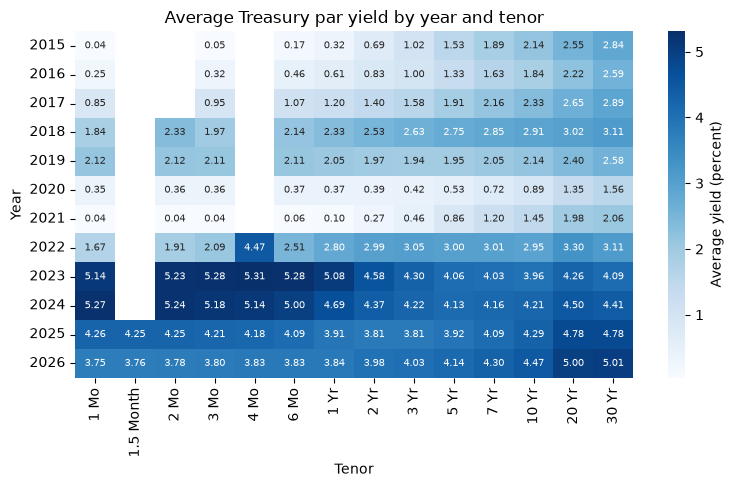

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# the table rounded to 2 decimal places, as printed above
# annot=True writes each number in its cell, in small type so that 14 columns fit
sns.heatmap(year_tenor.round(2), annot=True, fmt='.2f', annot_kws={'size': 7}, cmap='Blues',
            cbar_kws={'label': 'Average yield (percent)'}, ax=ax)

ax.set_title('Average Treasury par yield by year and tenor')
ax.set_xlabel('Tenor')
ax.set_ylabel('Year')

plt.show()

* The palest rows are 2020 and 2021, and at the short end 2015 and 2016. The lowest cell is 0.04 percent, which appears for the `1 Mo` in 2015 and for the `1 Mo`, `2 Mo`, and `3 Mo` in 2021.
* The darkest cells are the short tenors in 2023 and 2024. The highest is 5.31 percent, the `4 Mo` in 2023.
* Reading along a row shows the average curve of that year. In 2021 the colour deepens from left to right, from 0.04 to 2.06 percent. In 2023 it is darkest at the short end, 5.31 percent for the `4 Mo`, and palest at the `10 Yr`, 3.96 percent.
* The empty cells in the top left are the three tenors before their first values. A heatmap leaves a missing value uncoloured.
* The dark `4 Mo` cell for 2022 is the part-year average from the last section. On the chart it looks like a jump between its neighbours. It is an average over different dates.

### 3.5 One tenor by year, as box plots

Q. Draw the distribution of the 10 Yr yield in each year.

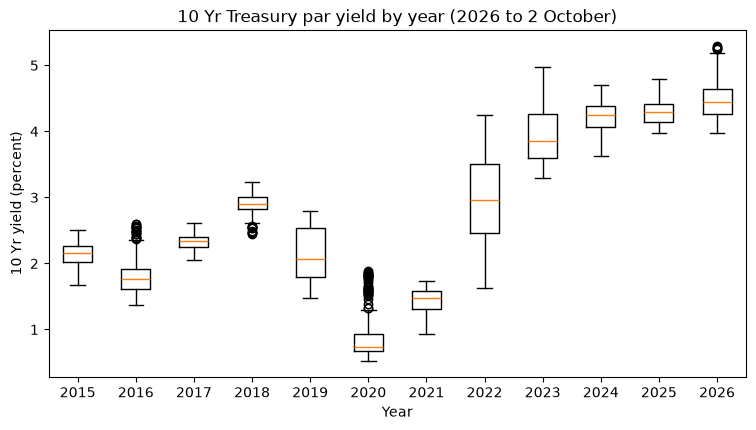

Median 10 Yr yield in 2020: 0.74 percent


In [24]:
# the years in the file, as a list
years = yields.index.year.unique().tolist()

# one group of 10 Yr yields per year
groups = [yields.loc[str(year), '10 Yr'] for year in years]

fig, ax = plt.subplots(figsize=(9, 4.5))

# ax.boxplot() draws one box for each group in the list. tick_labels= names the boxes.
ax.boxplot(groups, tick_labels=years)

ax.set_title('10 Yr Treasury par yield by year (2026 to 2 October)')
ax.set_xlabel('Year')
ax.set_ylabel('10 Yr yield (percent)')

plt.show()

print('Median 10 Yr yield in 2020:', yields.loc['2020', '10 Yr'].median(), 'percent')

* Each box is one year of daily `10 Yr` yields: the middle half of the year's values in the box, the median as the line across it.
* The tallest spread is 2022, whose values run from 1.63 to 4.25 percent, the 262 basis point range of section 3.2. The most compact is 2017, from 2.05 to 2.62 percent.
* The lowest box is 2020, with a median of 0.74 percent. Its circles above the upper whisker are the days of that year when the yield was well above the rest of the year's values. The year's highest value was 1.88 percent.
* `yields.loc[str(year), '10 Yr']` is the partial string indexing of section 2.1, with the year turned into text by `str()`.
* A box plot of a year of a time series shows where the values were. It does not show the order they came in. The line plot in the next section shows that.

**Excel side by side.** A heatmap is the table with Home, Conditional Formatting, Color Scales applied to its cells. A box plot by year is Insert, Insert Statistic Chart, Box and Whisker, in Excel 2016 and later, with the year column as the category and the `10 Yr` column as the values.

**Observations: yields by tenor and by year**

* Over the whole span the `10 Yr` averaged 2.76 percent, between a low of 0.52 and a high of 5.29.
* By year, the `10 Yr` mean was lowest in 2020 at 0.89 percent and highest among whole years in 2025 at 4.29 percent. The widest yearly range was 262 basis points in 2022 and the narrowest 57 in 2017.
* In 2023 and 2024 the average `3 Mo` yield was above the average `10 Yr` yield. In the other ten years it was below.
* Averages of the three part-span tenors cover fewer dates than the rest, and a cell such as `4 Mo` in 2022 is a part-year average.

## 4.0 Yields over time

### 4.1 Four tenors on one chart

Q. Draw the 3 Mo, 2 Yr, 10 Yr, and 30 Yr yields over the whole span.

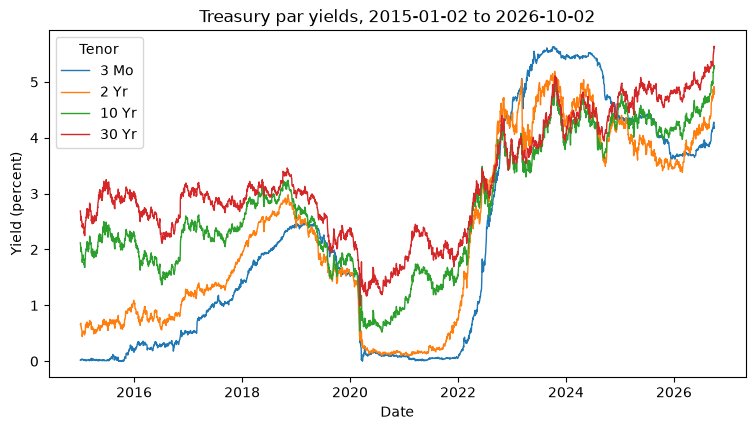

In [25]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# one line per tenor: the dates on the x axis, the yield on the y axis
for tenor in main:
    ax.plot(yields.index, yields[tenor], linewidth=1, label=tenor)

ax.legend(title='Tenor')
ax.set_title('Treasury par yields, 2015-01-02 to 2026-10-02')
ax.set_xlabel('Date')
ax.set_ylabel('Yield (percent)')

plt.show()

* matplotlib reads the `DatetimeIndex` and labels the x axis in years without being asked.
* The `3 Mo` line is close to zero in 2015 and again from 2020 to 2021. The `10 Yr` and `30 Yr` lines are at their lowest in 2020. All four are higher at the end of the span than at the start.
* The order of the lines changes. In the early years the `30 Yr` is on top and the `3 Mo` at the bottom. In 2023 and 2024 the `3 Mo` is on top.
* The chart shows 11,760 points, four tenors on 2,940 dates. It gives the shape. The dates and values behind the shape come from the table.

Q. On how many days was each of the four tenors the highest of the four?

In [26]:
# idxmax(axis=1) works along each row and returns the name of the column with the highest value
highest = yields[main].idxmax(axis=1)

# over the whole span
print(highest.value_counts())

# in 2023 and in 2024
print('2023:', highest.loc['2023'].value_counts().to_dict())
print('2024:', highest.loc['2024'].value_counts().to_dict())

30 Yr    2335
3 Mo      508
2 Yr       95
10 Yr       2
Name: count, dtype: int64
2023: {'3 Mo': 250}
2024: {'3 Mo': 235, '30 Yr': 15}


* The `30 Yr` was the highest of the four on 2,335 of the 2,940 days, the `3 Mo` on 508, the `2 Yr` on 95, and the `10 Yr` on 2.
* In 2023 the `3 Mo` was the highest of the four on all 250 days. In 2024 it was the highest on 235 days and the `30 Yr` on 15.
* `idxmax()` so far has worked down a column. With `axis=1` it works along a row, and its answer is a column name. When two tenors are tied on a day it returns the first in the list.

Q. On which date was each of the four tenors highest and lowest?

In [27]:
for tenor in main:
    # idxmax() and idxmin() return the row label, here the date, of the highest and lowest value
    high_date = yields[tenor].idxmax()
    low_date = yields[tenor].idxmin()

    print(tenor, '- highest', yields[tenor].max(), 'on', high_date.date(),
          ' lowest', yields[tenor].min(), 'on', low_date.date())

# idxmax() and idxmin() return the first date when a value is tied. Count the ties.
print('Days the 3 Mo was at its lowest:', (yields['3 Mo'] == yields['3 Mo'].min()).sum())
print('Days the 3 Mo was at its highest:', (yields['3 Mo'] == yields['3 Mo'].max()).sum())

3 Mo - highest 5.63 on 2023-10-06  lowest 0.0 on 2015-09-18
2 Yr - highest 5.19 on 2023-10-17  lowest 0.09 on 2021-02-05
10 Yr - highest 5.29 on 2026-09-30  lowest 0.52 on 2020-08-04
30 Yr - highest 5.64 on 2026-09-30  lowest 0.99 on 2020-03-09
Days the 3 Mo was at its lowest: 13
Days the 3 Mo was at its highest: 2


* The `10 Yr` was lowest at 0.52 percent on 2020-08-04 and highest at 5.29 percent on 2026-09-30. The `30 Yr` was lowest at 0.99 percent on 2020-03-09 and highest at 5.64 percent on 2026-09-30.
* The `2 Yr` was lowest at 0.09 percent on 2021-02-05 and highest at 5.19 percent, first reached on 2023-10-17.
* The `3 Mo` was at its low of 0.00 percent on 13 dates, the first of them 2015-09-18, and at its high of 5.63 percent on 2 dates, the first of them 2023-10-06.
* `idxmax()` and `idxmin()` return one date. When the value is tied they return the first, so a count of the ties belongs next to them.

**Excel side by side.** For the chart, select column A and the four tenor columns and choose Insert, Line. With real dates in column A, Excel draws a date axis. The highest value and its date are two formulas:

| Job | pandas | Excel | Result for the `10 Yr` |
| --- | --- | --- | --- |
| Highest value | `yields['10 Yr'].max()` | `=MAX(M2:M2941)` | 5.29 |
| Its date | `yields['10 Yr'].idxmax()` | `=XLOOKUP(MAX(M2:M2941), M2:M2941, A2:A2941)` | 2026-09-30 |
| Its date, older form | | `=INDEX(A2:A2941, MATCH(MAX(M2:M2941), M2:M2941, 0))` | 2026-09-30 |
| Lowest value and its date | `min()`, `idxmin()` | `=XLOOKUP(MIN(M2:M2941), M2:M2941, A2:A2941)` | 2020-08-04 |

`XLOOKUP` and `MATCH` with 0 both return the first match, as `idxmax()` does. The result shows as a date once the cell has a date format.

### 4.2 From daily to month-end

A daily series is more detail than a reference sheet needs. `resample()` changes the frequency of a time series. It is a `groupby` for dates: it puts the rows into periods, here months, and then a method says what to keep from each period.

**Predict 4**

```
month_end = yields.resample('ME').last()
print(month_end.shape)
```

`'ME'` means month end, and `last()` keeps the last row of each month. The file runs from January 2015 to October 2026. What is printed?

> A) (12, 14), one row for each calendar month from January to December
>
> B) (141, 14), one row for each complete month
>
> C) (142, 14), one row for each month that has any rows

Decide, then run the cell.

In [28]:
# 'ME' groups the rows by calendar month. last() keeps the last value of each month.
month_end = yields.resample('ME').last()

print(month_end.shape)
print(month_end[['2 Yr', '10 Yr']].head(3))
print(month_end[['2 Yr', '10 Yr']].tail(3))

(142, 14)
            2 Yr  10 Yr
date                   
2015-01-31  0.47   1.68
2015-02-28  0.63   2.00
2015-03-31  0.56   1.94
            2 Yr  10 Yr
date                   
2026-08-31  4.34   4.75
2026-09-30  4.88   5.29
2026-10-31  4.83   5.28


* The answer is C: (142, 14). Eleven whole years are 132 months, and 2026 adds 10, January to October.
* The first three month-end `10 Yr` values are 1.68, 2.00, and 1.94 percent.
* Look at the last row. It is labelled 2026-10-31 and holds 4.83 and 5.28 percent, which are the values of 2026-10-02, the last date in the file. `resample()` made a row for October 2026 from the two rows it had. A part month looks like any other month in the result, so check the last row of a resampled table against the last date of the data.
* In versions of pandas before 2.2 the code for month end is `'M'`.

Q. The first row is labelled 2015-01-31. Is that date in the file?

In [29]:
print('2015-01-31 in the file:', '2015-01-31' in yields.index)

# the last date of January 2015 in the file, and its 10 Yr yield
january = yields.loc['2015-01']
print('Last date of January 2015 in the file:', january.index.max().date())
print('10 Yr on that date:', january['10 Yr'].iloc[-1], 'percent')

# the mean of the month is a different number from its last value
print('10 Yr mean of January 2015:', round(january['10 Yr'].mean(), 2), 'percent')

2015-01-31 in the file: False
Last date of January 2015 in the file: 2015-01-30
10 Yr on that date: 1.68 percent
10 Yr mean of January 2015: 1.88 percent


* 2015-01-31 is not in the file. The last date of that month in the file is 2015-01-30, and its `10 Yr` yield is 1.68 percent, the value in the first row of `month_end`.
* The label of a resampled row is the calendar end of the period. The value is the last one found inside the period. The two need not be the same day.
* `resample('ME').mean()` would give the monthly average in place of the month-end value: 1.88 percent for January 2015 against 1.68. A column called monthly should say which of the two it is.

**Excel side by side.** `=EOMONTH(A2, 0)` returns the last calendar day of the month of the date in A2, which is 2015-01-31 for every date in January 2015. The month-end value is a lookup that accepts the nearest earlier date: `=XLOOKUP(DATE(2015, 1, 31), A2:A2941, M2:M2941, , -1)` returns 1.68. The fifth argument, -1, means an exact match or the next smaller item, so the lookup lands on 2015-01-30. The monthly average is `=AVERAGEIFS(M2:M2941, A2:A2941, ">=" & DATE(2015, 1, 1), A2:A2941, "<=" & DATE(2015, 1, 31))`, which returns 1.88.

**Observations: yields over time**

* The `10 Yr` was lowest on 2020-08-04 at 0.52 percent and highest on 2026-09-30 at 5.29 percent. The `30 Yr` high, 5.64 percent, is on the same date.
* The `3 Mo` was at 0.00 percent on 13 dates and peaked at 5.63 percent, first on 2023-10-06.
* Resampled to month end, the 2,940 daily rows become 142 monthly rows. The last one is a part month.

## 5.0 The curve on chosen dates

A row of the table is the curve on one date: the yield at each tenor. To draw it with the tenors spaced by their length, each tenor name needs a number of years.

Q. Build a mapping from tenor name to years.

In [30]:
# a dictionary from the tenor's name to its length in years
tenor_years = {
    '1 Mo': 1 / 12, '1.5 Month': 1.5 / 12, '2 Mo': 2 / 12, '3 Mo': 3 / 12, '4 Mo': 4 / 12, '6 Mo': 6 / 12,
    '1 Yr': 1, '2 Yr': 2, '3 Yr': 3, '5 Yr': 5, '7 Yr': 7, '10 Yr': 10, '20 Yr': 20, '30 Yr': 30,
}

# every tenor in the table should be in the dictionary
print('Tenors in the table:', len(tenors), ' in the dictionary:', len(tenor_years))
print('Any tenor without a number:', [tenor for tenor in tenors if tenor not in tenor_years])

Tenors in the table: 14  in the dictionary: 14
Any tenor without a number: []


* 14 and 14, and the list of tenors with no number is empty. The dictionary is a small lookup table, like the rating scale of the earlier notebooks.

Three dates are chosen by a rule, not by eye: the first date in the file, the last date, and the date on which the `10 Yr` yield was furthest below the `2 Yr` yield. Section 6.0 finds that date to be 2023-07-03.

Q. Draw the curve on those three dates.

2015-01-02 - 1 Mo: 0.02  2 Yr: 0.66  10 Yr: 2.12  30 Yr: 2.69
2023-07-03 - 1 Mo: 5.27  2 Yr: 4.94  10 Yr: 3.86  30 Yr: 3.87
2026-10-02 - 1 Mo: 4.04  2 Yr: 4.83  10 Yr: 5.28  30 Yr: 5.63


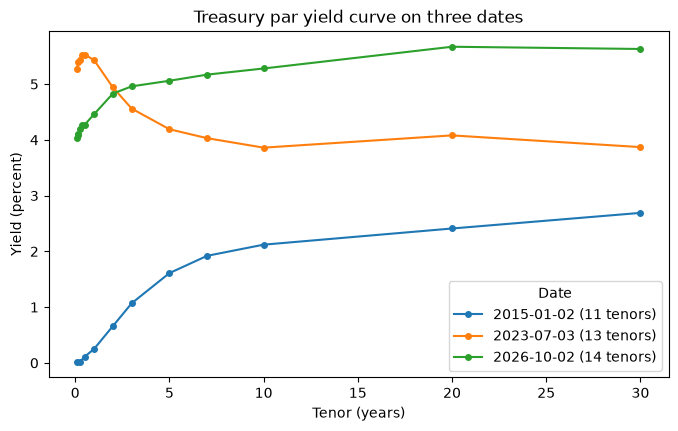

In [31]:
chosen = ['2015-01-02', '2023-07-03', '2026-10-02']

fig, ax = plt.subplots(figsize=(8, 4.5))

for day in chosen:
    # the row for that date, without the tenors that have no value on it
    curve = yields.loc[day, tenors].dropna()

    # the x value of each point is the tenor's length in years
    x = [tenor_years[tenor] for tenor in curve.index]

    ax.plot(x, curve.values, marker='o', markersize=4, label=day + ' (' + str(len(curve)) + ' tenors)')
    print(day, '- 1 Mo:', curve['1 Mo'], ' 2 Yr:', curve['2 Yr'], ' 10 Yr:', curve['10 Yr'], ' 30 Yr:', curve['30 Yr'])

ax.legend(title='Date')
ax.set_title('Treasury par yield curve on three dates')
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Yield (percent)')

plt.show()

* On 2015-01-02 the curve rose from 0.02 percent at `1 Mo` to 2.69 percent at `30 Yr`. It has 11 points: three tenors have no value on that date.
* On 2023-07-03 it was highest at the short end: 5.27 percent at `1 Mo`, 4.94 at `2 Yr`, 3.86 at `10 Yr`, and 3.87 at `30 Yr`. It has 13 points.
* On 2026-10-02 it rose from 4.04 percent at `1 Mo` to 5.28 at `10 Yr` and 5.63 at `30 Yr`, with all 14 tenors. The `20 Yr`, 5.67 percent, was above the `30 Yr`.
* `dropna()` is right here. It removes the tenors with no value on that one date, so that the line is drawn through the points that exist. Section 2.4 showed they are tenors whose first value comes later.
* The six tenors up to six months sit close together at the left edge, because the axis is in years. That is the true spacing.

**Excel side by side.** Put the tenor lengths in one row, 0.083 for `1 Mo` up to 30 for `30 Yr`, with the yields of the chosen date in the row beneath, and choose Insert, Scatter, Scatter with Straight Lines and Markers. A Scatter chart places each point by its x value, as `ax.plot()` does. A Line chart spaces its categories evenly when they are text, so the tenor names as labels would put `1 Mo` and `2 Mo` as far apart as `20 Yr` and `30 Yr`.

**Observations: the curve on chosen dates**

* On the first date of the file the curve ran from 0.02 to 2.69 percent, and on the last from 4.04 to 5.63 percent.
* On 2023-07-03 the `1 Mo` yield, 5.27 percent, was 141 basis points above the `10 Yr` yield, 3.86 percent.
* The number of points on a curve depends on the date: 11, 13, and 14 on the three dates chosen.

## 6.0 A spread between two tenors

### 6.1 A new column

Q. Work out the 10 Yr yield less the 2 Yr yield for every date, in basis points.

In [32]:
# the difference is in percent. Times 100 gives basis points.
# round() removes the tiny error of decimal arithmetic, and astype(int) shows whole numbers
yields['spread_bp'] = ((yields['10 Yr'] - yields['2 Yr']) * 100).round().astype(int)

print(yields[['2 Yr', '10 Yr', 'spread_bp']].head(3))
print(yields[['2 Yr', '10 Yr', 'spread_bp']].tail(3))

            2 Yr  10 Yr  spread_bp
date                              
2015-01-02  0.66   2.12        146
2015-01-05  0.68   2.04        136
2015-01-06  0.65   1.97        132
            2 Yr  10 Yr  spread_bp
date                              
2026-09-30  4.88   5.29         41
2026-10-01  4.78   5.24         46
2026-10-02  4.83   5.28         45


* One subtraction worked on all 2,940 rows at once, as column arithmetic has since week 2. On 2015-01-02 the spread was 146 basis points, 2.12 less 0.66 percent. On 2026-10-02 it was 45 basis points, 5.28 less 4.83.
* The unit is in the column name. `spread_bp` cannot be mistaken for a yield in percent.
* `yields` now has 15 columns. The list `tenors` still holds the 14 tenor names, which is why it was saved in section 1.3.

Q. What are the mean, lowest, and highest spread, and on which dates?

In [33]:
spread = yields['spread_bp']

print('Mean:', round(spread.mean(), 1), 'basis points')
print('Median:', spread.median(), 'basis points')
print('Lowest:', spread.min(), 'on', spread.idxmin().date())
print('Highest:', spread.max(), 'first on', spread.idxmax().date(), ' days at that value:', (spread == spread.max()).sum())

Mean: 48.1 basis points
Median: 50.0 basis points
Lowest: -108 on 2023-07-03
Highest: 177 first on 2015-06-26  days at that value: 2


* The mean spread over the span is 48.1 basis points and the median is 50.
* The lowest is -108 basis points, on 2023-07-03: a `10 Yr` of 3.86 percent less a `2 Yr` of 4.94. That is the middle date of the curve chart.
* The highest is 177 basis points, on 2 dates, the first of them 2015-06-26.

### 6.2 The spread over time

Q. Draw the spread, with a reference line at zero.

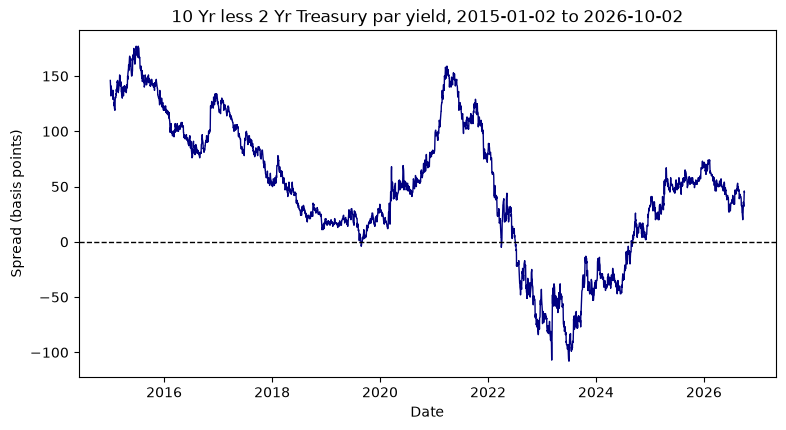

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(yields.index, yields['spread_bp'], linewidth=1, color='navy')

# axhline() draws a horizontal line across the chart at the y value given
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_title('10 Yr less 2 Yr Treasury par yield, 2015-01-02 to 2026-10-02')
ax.set_xlabel('Date')
ax.set_ylabel('Spread (basis points)')

plt.show()

* The spread starts at 146 basis points, falls to the zero line by 2019, rises to above 150 in 2021, and falls again to its low of -108 in 2023. It ends at 45.
* The dashed line makes the sign readable. Below it, the `2 Yr` yield was above the `10 Yr` yield.
* The line touches zero around 2019 and stays below it for a long stretch from 2022 to 2024. A chart cannot say how many days that was. A count can.

### 6.3 Days below zero

Q. On how many days was the spread below zero, and on how many was it exactly zero?

In [35]:
# a comparison gives True or False for each date, and sum() counts the Trues
below = yields['spread_bp'] < 0

print('Days below zero:', below.sum())
print('Days at exactly zero:', (yields['spread_bp'] == 0).sum())
print('Share of all days below zero:', round(below.mean() * 100, 1), 'percent')

# the first and the last date below zero
print('First:', yields.index[below].min().date())
print('Last:', yields.index[below].max().date())

Days below zero: 544
Days at exactly zero: 7
Share of all days below zero: 18.5 percent
First: 2019-08-27
Last: 2024-09-05


* 544 of the 2,940 days, 18.5 percent, had a spread below zero. On 7 more days it was exactly zero.
* The first day below zero was 2019-08-27 and the last was 2024-09-05.
* The mean of a True and False column is the share of Trues, because True counts as 1 and False as 0.
* Whether zero counts as below is a decision, and `<` and `<=` give 544 and 551. State which was used.

Q. How many days below zero were there in each year?

In [36]:
# group the True and False values by year and count the Trues in each
below_by_year = below.groupby(yields.index.year).sum()
print(below_by_year)

print('Total:', below_by_year.sum())
print('Rows in 2023:', len(yields.loc['2023']))

date
2015      0
2016      0
2017      0
2018      0
2019      3
2020      0
2021      0
2022    125
2023    250
2024    166
2025      0
2026      0
Name: spread_bp, dtype: int64
Total: 544
Rows in 2023: 250


* Four years have days below zero: 3 in 2019, 125 in 2022, 250 in 2023, and 166 in 2024. The other eight years have none. The four add up to 544.
* 2023 has 250 rows, so the spread was below zero on every date of that year in the file.
* The three days in 2019 are the brief touch on the chart. The count shows how different that was from 2022 to 2024.

**Excel side by side.** The spread is a helper column. In Q2, `=(M2 - I2) * 100`, filled down, which gives 146 in the first row.

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| The spread | `(yields['10 Yr'] - yields['2 Yr']) * 100` | `=(M2 - I2) * 100` in column Q | 146 on the first date |
| Days below zero | `(yields['spread_bp'] < 0).sum()` | `=COUNTIF(Q2:Q2941, "<0")` | 544 |
| Days below zero in one year | `below.groupby(yields.index.year).sum()` | `=COUNTIFS(P2:P2941, 2023, Q2:Q2941, "<0")` | 250 |
| Lowest spread | `spread.min()` | `=MIN(Q2:Q2941)` | -108 |
| Its date | `spread.idxmin()` | `=XLOOKUP(MIN(Q2:Q2941), Q2:Q2941, A2:A2941)` | 2023-07-03 |

Column P is the year helper from section 2.2. For the chart, select columns A and Q and choose Insert, Line. With negative values in the data, the horizontal axis of the chart is drawn at zero by default, which serves as the zero reference line.

**Observations: a spread between two tenors**

* The `10 Yr` less `2 Yr` spread averaged 48.1 basis points over the span, between a high of 177 on 2015-06-26 and a low of -108 on 2023-07-03.
* It was below zero on 544 days: 3 in 2019, 125 in 2022, all 250 in 2023, and 166 in 2024, the last of them 2024-09-05.
* On the last date in the file it was 45 basis points.

## 7.0 Daily changes

### 7.1 The change from one row to the next

`diff()` takes each value less the value in the row before it. On a daily series in date order, that is the daily change.

**Predict 5**

```
changes = (yields[main].diff() * 100).round()
print(changes['10 Yr'].count())
```

The table has 2,940 rows. `count()` counts the values that are not missing. What is printed?

> A) 2940
>
> B) 2939
>
> C) 2938

Decide, then run the cell.

In [37]:
# diff() is each row less the row before. Times 100 turns percent into basis points.
# round() removes the tiny error of decimal arithmetic. Every change is a whole number of basis points.
changes = (yields[main].diff() * 100).round()

print(changes['10 Yr'].count())
changes.head(3)

2939


,3 Mo,2 Yr,10 Yr,30 Yr
date,,,,
2015-01-02,NaN,NaN,NaN,NaN
2015-01-05,1.0,2.0,-8.0,-9.0
2015-01-06,0.0,-3.0,-7.0,-8.0


* The answer is B: 2,939. The first row has no row before it, so its change is `NaN`. Every other row has one.
* On 2015-01-05 the `10 Yr` change was -8 basis points: 2.04 percent less 2.12 the day before.
* The unit matters here more than anywhere. `yields['10 Yr'].diff()` alone is in percent, and its value for that day is -0.08. Reported as "-0.08 basis points" it would be wrong by a factor of 100. Multiply by 100, and say basis points.
* A change is from one **row** to the next. Across a weekend or a day with no row, it is the change over more than one calendar day.

Q. How do the daily changes of the four tenors compare?

In [38]:
changes.describe().round(2)

,3 Mo,2 Yr,10 Yr,30 Yr
count,2939.00,2939.00,2939.00,2939.00
mean,0.14,0.14,0.11,0.10
std,2.95,5.19,5.30,5.05
min,-23.00,-57.00,-30.00,-31.00
25%,-1.00,-2.00,-3.00,-3.00
50%,0.00,0.00,0.00,0.00
75%,1.00,3.00,3.00,3.00
max,34.00,34.00,29.00,29.00


* The mean daily change of each tenor is close to zero, between 0.10 and 0.14 basis points, and the median is 0 for all four.
* The standard deviation is 2.95 basis points for the `3 Mo`, 5.19 for the `2 Yr`, 5.30 for the `10 Yr`, and 5.05 for the `30 Yr`.
* The largest one-day fall in the table is -57 basis points, in the `2 Yr`. The largest one-day rise is 34 basis points, in both the `3 Mo` and the `2 Yr`.
* For the `10 Yr`, the middle half of the daily changes lies between -3 and 3 basis points, and the extremes are -30 and 29.

### 7.2 The distribution of the 10 Yr daily change

Q. Draw the histogram of the 10 Yr daily changes.

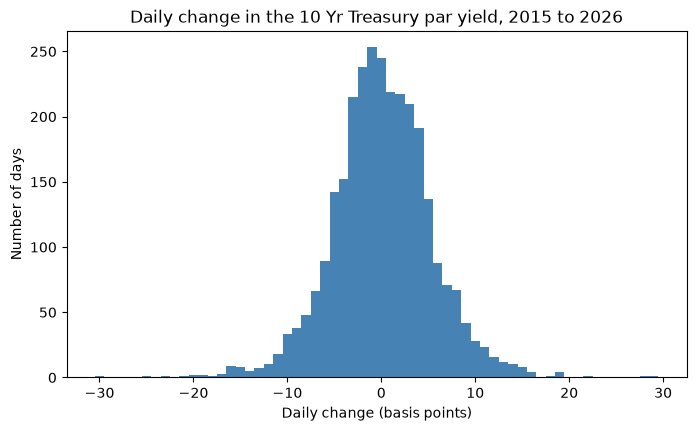

Days with no change: 245
Days up: 1351  days down: 1343
Days within 5 basis points of zero: 2219 of 2939


In [39]:
# the first row is NaN, so leave it out
ten_year_changes = changes['10 Yr'].dropna()

fig, ax = plt.subplots(figsize=(8, 4.5))

# the changes are whole basis points, so use one bar per basis point, centred on the whole number
# the edges of the bars are -30.5, -29.5, and so on up to 29.5
edges = [value - 0.5 for value in range(-30, 31)]
ax.hist(ten_year_changes, bins=edges, color='steelblue')

ax.set_title('Daily change in the 10 Yr Treasury par yield, 2015 to 2026')
ax.set_xlabel('Daily change (basis points)')
ax.set_ylabel('Number of days')

plt.show()

print('Days with no change:', (ten_year_changes == 0).sum())
print('Days up:', (ten_year_changes > 0).sum(), ' days down:', (ten_year_changes < 0).sum())
print('Days within 5 basis points of zero:', (ten_year_changes.abs() <= 5).sum(), 'of', len(ten_year_changes))

* The histogram is centred near zero and close to symmetric: 1,351 days up, 1,343 days down, and 245 days with no change.
* 2,219 of the 2,939 daily changes, 75.5 percent, were within 5 basis points of zero in either direction.
* The bars thin out quickly beyond 10 basis points in either direction, and the few days near -30 and 29 are too few to see at this scale. The next question finds them.
* `abs()` drops the sign, so that a fall of 6 and a rise of 6 are both counted as a move of 6.

### 7.3 The largest moves

Q. Which were the five largest one-day rises and the five largest one-day falls in the 10 Yr yield?

In [40]:
# nlargest() and nsmallest() return the highest and lowest values with their row labels, the dates
print('Largest rises (basis points):')
print(changes['10 Yr'].nlargest(5))

print('Largest falls (basis points):')
print(changes['10 Yr'].nsmallest(5))

Largest rises (basis points):
date
2020-03-17    29.0
2022-06-13    28.0
2020-03-10    22.0
2016-11-09    19.0
2022-09-22    19.0
Name: 10 Yr, dtype: float64
Largest falls (basis points):
date
2022-11-10   -30.0
2022-09-28   -25.0
2023-03-10   -23.0
2020-03-16   -21.0
2020-03-09   -20.0
Name: 10 Yr, dtype: float64


* The largest one-day rise in the `10 Yr` is 29 basis points, on 2020-03-17. The next are 28 on 2022-06-13 and 22 on 2020-03-10.
* The largest one-day fall is -30 basis points, on 2022-11-10. The next are -25 on 2022-09-28 and -23 on 2023-03-10.
* The dates come back with the values, because the dates are the index. Four of the ten dates are in March 2020 and four are in 2022. That is where these dates fall in the file. The file does not say why.
* A rise of 19 basis points happened on four dates, and `nlargest(5)` has room for two of them. When values are tied it keeps the earliest rows.

Q. Show the yields around the largest rise.

In [41]:
# the rows either side of 2020-03-17, with the level and the change side by side
around = yields.loc['2020-03-13':'2020-03-19', ['10 Yr']].copy()
around['change_bp'] = changes.loc['2020-03-13':'2020-03-19', '10 Yr']
print(around)

            10 Yr  change_bp
date                        
2020-03-13   0.94        6.0
2020-03-16   0.73      -21.0
2020-03-17   1.02       29.0
2020-03-18   1.18       16.0
2020-03-19   1.12       -6.0


* The `10 Yr` went from 0.73 percent on 2020-03-16 to 1.02 percent on 2020-03-17, the 29 basis point rise. The day before, it had fallen 21 basis points.
* Checking a change against the two levels it came from takes one cell, and confirms both the arithmetic and the units.

Q. In each year, on how many days did the 10 Yr yield move by 10 basis points or more, in either direction?

In [42]:
# True on the days with a move of 10 basis points or more, up or down
big_move = changes['10 Yr'].abs() >= 10

big_by_year = big_move.groupby(yields.index.year).sum()
print(big_by_year)
print('Total:', big_by_year.sum())

date
2015    20
2016     9
2017     2
2018     2
2019    11
2020    15
2021     7
2022    48
2023    55
2024    22
2025    14
2026     6
Name: 10 Yr, dtype: int64
Total: 211


* 211 days in all. The most are in 2023, with 55, and 2022, with 48. The fewest are in 2017 and 2018, with 2 each.
* This is the same pattern of code as the days below zero: a True and False column, grouped by year, and summed.

**Excel side by side.** The daily change is a helper column that starts in the second data row. In R3, `=(M3 - M2) * 100`, filled down to R2941. R2 stays empty, as the first `diff()` is `NaN`.

| Job | pandas | Excel | Result for the `10 Yr` |
| --- | --- | --- | --- |
| Daily change | `yields['10 Yr'].diff() * 100` | `=(M3 - M2) * 100` in column R | -8 on 2015-01-05 |
| Largest rise | `changes['10 Yr'].max()` | `=MAX(R3:R2941)` | 29 |
| Its date | `changes['10 Yr'].idxmax()` | `=XLOOKUP(MAX(R3:R2941), R3:R2941, A3:A2941)` | 2020-03-17 |
| Its date, older form | | `=INDEX(A3:A2941, MATCH(MAX(R3:R2941), R3:R2941, 0))` | 2020-03-17 |
| Second largest rise | `changes['10 Yr'].nlargest(2)` | `=LARGE(R3:R2941, 2)` | 28 |
| Largest fall | `changes['10 Yr'].min()` | `=MIN(R3:R2941)` | -30 |
| Second largest fall | `changes['10 Yr'].nsmallest(2)` | `=SMALL(R3:R2941, 2)` | -25 |
| Standard deviation | `changes['10 Yr'].std()` | `=STDEV.S(R3:R2941)` | 5.30 |

The histogram is Insert, Insert Statistic Chart, Histogram on column R.

**Observations: daily changes**

* The `10 Yr` daily change has a mean near zero and a standard deviation of 5.30 basis points. 75.5 percent of days were within 5 basis points of zero.
* Its largest one-day rise was 29 basis points on 2020-03-17 and its largest one-day fall was -30 on 2022-11-10.
* Days with a `10 Yr` move of 10 basis points or more numbered 2 in each of 2017 and 2018 and 55 in 2023.
* Across the four tenors, the largest one-day move in the table is a fall of 57 basis points in the `2 Yr`.

## Summary

**The file**

| Check | Result |
| --- | --- |
| Source | U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates, retrieved 2026-10-03, figures as published |
| Span | 2015-01-02 to 2026-10-02 |
| Rows and tenors | 2,940 dates, 14 tenors |
| Order and repeats | in date order, no date repeated |
| Weekends | none |
| Weekdays with no row | 126 of 3,066 |
| Rows per whole year | 249 to 251. 2026 has 190 and is a part year. |
| Blank cells | 5,432, all in three tenors before their first date: `2 Mo` from 2018-10-16, `4 Mo` from 2022-10-19, `1.5 Month` from 2025-02-18 |
| What was changed | nothing. One column, `spread_bp`, was added. |

**What the data shows**

These describe the file. They are not a view, and none of them explains a move or says what comes next.

* Over the span, the `10 Yr` par yield averaged 2.76 percent. Its low was 0.52 percent on 2020-08-04 and its high 5.29 percent on 2026-09-30.
* By year, the `10 Yr` mean was lowest in 2020, 0.89 percent, and highest among whole years in 2025, 4.29 percent. Its range within a year was widest in 2022, 262 basis points, and narrowest in 2017, 57.
* The `3 Mo` was at 0.00 percent on 13 dates and reached 5.63 percent, first on 2023-10-06. Its yearly mean was above the `10 Yr` yearly mean in 2023 and 2024.
* The `10 Yr` less `2 Yr` spread averaged 48.1 basis points, with a high of 177 and a low of -108 on 2023-07-03. It was below zero on 544 days, in 2019, 2022, 2023, and 2024, and on every date in the file in 2023.
* The `10 Yr` daily change had a standard deviation of 5.30 basis points. The largest rise was 29 on 2020-03-17 and the largest fall -30 on 2022-11-10.
* On the last date, 2026-10-02, the `2 Yr` was 4.83 percent, the `10 Yr` 5.28 percent, and the spread 45 basis points.

**What was new today**

| Job | Code |
| --- | --- |
| Read dates as the index | `pd.read_csv(file, parse_dates=['date'], index_col='date')` |
| Select a date, a month, a year | `yields.loc['2020-03-09']`, `yields.loc['2020-03']`, `yields.loc['2020']` |
| Select a range of dates, both ends included | `yields.loc['2019-12-30':'2020-01-03']` |
| Group by year | `yields.groupby(yields.index.year)` |
| Weekdays with no row | `pd.date_range(start, end, freq='B').difference(yields.index)` |
| First date a column has a value | `yields['2 Mo'].first_valid_index()` |
| Wide to long | `yields.reset_index().melt(id_vars='date', var_name='tenor', value_name='yield_pct')` |
| Date of the highest value | `yields['10 Yr'].idxmax()` |
| Month-end values | `yields.resample('ME').last()` |
| Daily change in basis points | `yields['10 Yr'].diff() * 100` |
| The largest values with their dates | `changes['10 Yr'].nlargest(5)` |

**The habits to keep**

* State the source, the retrieval date, and the span of any real data, and say that the figures are as published.
* Say the unit every time: percent for a yield, basis points for a spread or a change.
* Put `count()` beside an average of any column that has blanks, and flag a part year or a part month.
* Describe a time series with dates and numbers. A table cannot say why a number moved.

The next notebook is a case study of a small trade blotter.

## Exercises

The exercises use the same file and ask about tenors and pairs the lesson did not examine: the `5 Yr`, the `30 Yr`, and the `10 Yr` against the `3 Mo`. The figures are U.S. Treasury par yields as published, retrieved 2026-10-03. Every answer describes the data. None is a view, and none explains a move.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on, say the unit, and where an exercise asks for a chart, give it a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and loads a fresh `yields` with the dates as the index. It prints the shape, (2940, 14), and the first and last date, 2015-01-02 to 2026-10-02.

In [43]:
import os

import matplotlib.pyplot as plt
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# a fresh copy of the file, with the dates as the index. In Colab it is read from GitHub.
if os.path.exists('../../../data/treasury_par_yields.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

yields = pd.read_csv(data_folder + 'treasury_par_yields.csv', parse_dates=['date'], index_col='date')

print(yields.shape)
print(yields.index.min().date(), 'to', yields.index.max().date())

(2940, 14)
2015-01-02 to 2026-10-02


### Exercise 1

Q. What was the `5 Yr` yield on 2022-06-15? How many rows does the file have for 2022, and what was the mean `5 Yr` yield in 2022, rounded to 2 decimal places? Store the answers in **ex1_yield**, **ex1_rows**, and **ex1_mean**.

In [44]:
ex1_yield = ...
ex1_rows = ...
ex1_mean = ...

In [45]:
check('Exercise 1 yield', ex1_yield, 3.38)
check('Exercise 1 rows', ex1_rows, 249)
check('Exercise 1 mean', ex1_mean, 3.0)

Exercise 1 yield: not attempted yet
Exercise 1 rows: not attempted yet
Exercise 1 mean: not attempted yet


### Exercise 2

Q. For the `30 Yr`, work out the mean, lowest, and highest yield in each year, and the range of each year in basis points. In which year was the range widest, and how many basis points was it? Store the answers in **ex2_year** and **ex2_range_bp**.

In [46]:
ex2_year = ...
ex2_range_bp = ...

In [47]:
check('Exercise 2 year', ex2_year, 2022)
check('Exercise 2 range', ex2_range_bp, 239)

Exercise 2 year: not attempted yet
Exercise 2 range: not attempted yet


### Exercise 3

Q. Work out the `10 Yr` yield less the `3 Mo` yield for every date, in whole basis points. On how many days was it below zero? Which year had the most such days? Store the answers in **ex3_days** and **ex3_year**. Draw the spread over time with a reference line at zero.

In [48]:
ex3_days = ...
ex3_year = ...

In [49]:
check('Exercise 3 days', ex3_days, 738)
check('Exercise 3 year', ex3_year, 2023)

Exercise 3 days: not attempted yet
Exercise 3 year: not attempted yet


### Exercise 4

Q. Work out the daily change of the `5 Yr` yield in basis points. What was the largest one-day rise and on which date? What was the largest one-day fall and on which date? Store the two changes in **ex4_rise** and **ex4_fall**, and the two dates as text such as `'2020-03-09'` in **ex4_rise_date** and **ex4_fall_date**. A date becomes text with `.strftime('%Y-%m-%d')`. Draw the histogram of the daily changes.

In [50]:
ex4_rise = ...
ex4_rise_date = ...
ex4_fall = ...
ex4_fall_date = ...

In [51]:
check('Exercise 4 largest rise', ex4_rise, 31.0)
check('Exercise 4 date of the rise', ex4_rise_date, '2022-06-13')
check('Exercise 4 largest fall', ex4_fall, -32.0)
check('Exercise 4 date of the fall', ex4_fall_date, '2022-11-10')

Exercise 4 largest rise: not attempted yet
Exercise 4 date of the rise: not attempted yet
Exercise 4 largest fall: not attempted yet
Exercise 4 date of the fall: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for the average `10 Yr` yield in each year of the file. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. How many years should the table have, and what should the 2025 figure be? The lesson worked both out in section 3.2. Then run the code. Does the answer agree with you?

In [52]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# load the data
data = pd.read_csv(data_folder + 'treasury_par_yields.csv', parse_dates=['date'], index_col='date')

# remove rows with missing values
data = data.dropna()

# average 10 Yr yield by year
by_year = data.groupby(data.index.year)['10 Yr'].mean().round(2)
print(by_year)

ex5_years = len(by_year)
ex5_mean_2025 = by_year.loc[2025]

print('Years in the table:', ex5_years)
print('Average 10 Yr yield in 2025:', ex5_mean_2025, 'percent')

date
2025    4.25
2026    4.47
Name: 10 Yr, dtype: float64
Years in the table: 2
Average 10 Yr yield in 2025: 4.25 percent


Q. Find the bug and fix the code in the cell above, so that **ex5_years** and **ex5_mean_2025** hold the right answers.

In [53]:
check('Exercise 5 years', ex5_years, 12)
check('Exercise 5 mean for 2025', ex5_mean_2025, 4.29)

Exercise 5 years: not yet. You have 2
Exercise 5 mean for 2025: not yet. You have 4.25
